In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
import numpy as np

In [43]:
(Xtr,ytr),(Xts,yts)=mnist.load_data()
Xtr=Xtr/255
Xts=Xts/255

In [44]:
ytr=to_categorical(ytr,10)
yts=to_categorical(yts,10)


In [45]:
initial_learning_rate=0.001
batch_size=64
epochs=20
def lr_schedule(epoch,lr):
    if epoch>0 and epoch%3==0:
        return lr/2
    return lr



In [46]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
]
)


In [47]:
optimizer=Adam(learning_rate=initial_learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])



In [48]:
lr_scheduler=LearningRateScheduler(lr_schedule)
history=model.fit(Xtr,ytr,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(Xts,yts),
          callbacks=[lr_scheduler])

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9206 - loss: 0.2740 - val_accuracy: 0.9591 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9656 - loss: 0.1162 - val_accuracy: 0.9692 - val_loss: 0.1022 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9758 - loss: 0.0806 - val_accuracy: 0.9743 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9852 - loss: 0.0501 - val_accuracy: 0.9774 - val_loss: 0.0763 - learning_rate: 5.0000e-04
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9882 - loss: 0.0402 - val_accuracy: 0.9785 - val_loss: 0.0726 - learning_rate: 5.0000e-04
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9903 - loss: 0.0334 - val_accuracy: 0.9778 - val_loss: 0.0706 - learning_rate: 5.0000e-04
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9946 - los

In [49]:
test_loss,test_accuracy=model.evaluate(Xts,yts)
print(test_loss,test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9814 - loss: 0.0690
0.06902102380990982 0.9814000129699707


In [50]:
#copy the code and tweak the values in a new file

TypeError: 'str' object is not callable

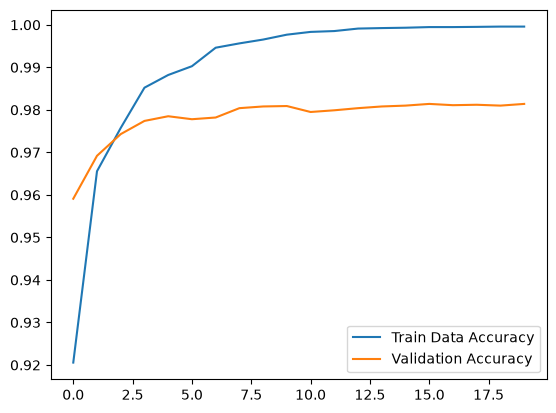

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="Train Data Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.show()

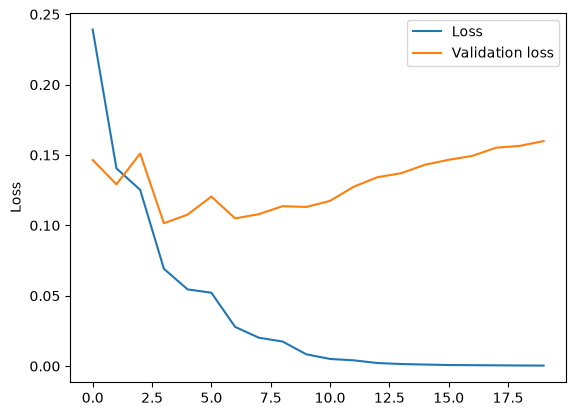

In [ ]:
plt.plot(history.history["loss"],label="Loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.legend()
plt.xlabel("ephocs")
plt.ylabel("Loss")
plt.show()